In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestRegressor, IsolationForest

In [ ]:

# Load CSV correctly
df = pd.read_csv(
    "player_stats.csv",
    sep=",",
    quotechar='"',   
    engine='python',
    encoding='utf-8'
)

# Remove unnecessary column
if 'Matches' in df.columns:
    df = df.drop(columns=['Matches'])

#  Clean text and remove parentheses
df = df.replace({r"[()]": ""}, regex=True)
df['Player'] = df['Player'].str.strip()
df['Nation'] = df['Nation'].str.replace('Â', '', regex=False).str.strip()
df['Squad'] = df['Squad'].str.replace('Â', '', regex=False).str.strip()


#  Handle multiple positions

df['PrimaryPos'] = df['Pos'].str.split(',').str[0].str.strip()


#  Convert numeric columns
-
num_cols = ['Age', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A',
            'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'xG', 'npxG', 'xAG',
            'npxG+xAG', 'PrgC', 'PrgP', 'PrgR']

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# -------------------------------
# Save cleaned dataset
# -------------------------------
df.to_csv("uefa_players_stats_cleaned.csv", index=False, encoding="utf-8")
print(" Cleaned dataset saved as 'uefa_players_stats_cleaned.csv'")


 Cleaned dataset saved as 'uefa_players_stats_cleaned.csv'


In [ ]:

#  Helper function: Load and clean any FBref dataset
def load_fbref_file(path):
    df = pd.read_csv(path, sep=",", quotechar='"', engine="python", encoding="utf-8")

    # remove weird chars and spaces
    df = df.replace({r"[()]": ""}, regex=True)

    # fix common text columns
    if "Player" in df.columns:
        df["Player"] = df["Player"].astype(str).str.strip()

    for col in ["Nation", "Squad"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.replace("Â", "", regex=False).str.strip()

    # handle multiple positions
    if "Pos" in df.columns:
        df["PrimaryPos"] = df["Pos"].astype(str).str.split(",").str[0].str.strip()

    # drop timestamp columns
    for col in df.columns:
        if "2025" in col or "00:00:00" in col:
            df = df.drop(columns=[col])

    # drop Ranking & Matches columns (useless)
    for col in ["Rk", "Matches", "Matche"]:
        if col in df.columns:
            df = df.drop(columns=[col])

    # convert numeric columns where possible
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="ignore")

    return df


df_def = load_fbref_file("./Defensive Stats/Player Defensive Actions.csv")
df_gk  = load_fbref_file("./Goalkeeping Stats/Player Goalkeeping.csv")
df_pas = load_fbref_file("./Passing Stats/Player Passing.csv")
df_pos = load_fbref_file("./Possession/Player Possession.csv")
df_sht = load_fbref_file("./Shooting/Shooting.csv")
df_std = load_fbref_file("./player_stats.csv")


#  Normalize merge keys AFTER LOADING (correct place)
def normalize_merge_keys(df):
    keys = ["Player", "Nation", "Squad", "Pos", "PrimaryPos", "Age", "Born"]
    for k in keys:
        if k in df.columns:
            df[k] = df[k].astype(str).str.strip()
    return df

df_std = normalize_merge_keys(df_std)
df_sht = normalize_merge_keys(df_sht)
df_pas = normalize_merge_keys(df_pas)
df_pos = normalize_merge_keys(df_pos)
df_def = normalize_merge_keys(df_def)
df_gk  = normalize_merge_keys(df_gk)
#  Fix duplicate columns in standard stats

dup_map = {
    "Ast": "Ast_total",
    "Gls": "Gls_total",
    "xG": "xG_total",
    "xAG": "xAG_total",
    "npxG": "npxG_total",
}
df_std = df_std.rename(columns=dup_map)
# Merge all datasets correctly
dfs = [df_std, df_sht, df_pas, df_pos, df_def, df_gk]

master = dfs[0]
for nxt in dfs[1:]:
    master = master.merge(
        nxt,
        on=["Player", "Nation", "Squad"],
        how="outer",
        suffixes=("", "_dup")
    )

# Remove duplicate columns created by merge
master = master.loc[:, ~master.columns.str.contains("_dup")]
master = master.loc[:, ~master.columns.duplicated()]

#  Clean duplicate columns created by merging
master = master.loc[:, ~master.columns.duplicated()]
#  Remove players without 90s played
if "90s" in master.columns:
    master = master[master["90s"].notna()]

# Save final merged dataset
master.to_csv("uefa_master_merged.csv", index=False, encoding="utf-8")
print(" Final Merged Dataset Saved as 'uefa_master_merged.csv'")
print("Shape:", master.shape)


C:\Users\melke\AppData\Local\Temp\ipykernel_18332\1953057000.py:34: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")
C:\Users\melke\AppData\Local\Temp\ipykernel_18332\1953057000.py:34: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")
C:\Users\melke\AppData\Local\Temp\ipykernel_18332\1953057000.py:34: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")
C:\Users\melke\AppData\Local\Temp\ipykernel_18332\1953057000.py:34: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_n

 Final Merged Dataset Saved as 'uefa_master_merged.csv'
Shape: (886, 113)


In [ ]:
#  Load your merged dataset
df = pd.read_csv("uefa_master_merged.csv")
print(" Initial shape:", df.shape)
# Ensure 90s is numeric
df["90s"] = pd.to_numeric(df["90s"], errors="coerce")

# Drop players without 90s played (cannot compute per90)
df = df[df["90s"] > 0].copy()  

#  Identify numeric columns suitable for per-90

exclude_cols = [
    "Player", "Nation", "Squad", "Pos", "PrimaryPos", 
    "Age", "Born", "Min", "MP", "Starts", "90s",
    "Save%", "CS%", "PSxG", "PSxG/SoT", "PSxG+/-", "/90",

    "Cmp%", "TotCmp%", "ShoCmp%", "MedCmp%", "LonCmp%",
    "KP", "PPA", "CrsPA", "PrgP",  
]


numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()


per90_candidates = [c for c in numeric_cols if c not in exclude_cols]

print(f"✓ Numeric columns: {len(numeric_cols)}")
print(f"✓ Per-90 eligible: {len(per90_candidates)}")

#Compute per-90 metrics efficiently
per90_dict = {}
for col in per90_candidates:
    per90_dict[col + "_per90"] = df[col] / df["90s"]

df_per90 = pd.DataFrame(per90_dict)
df_final = pd.concat([df, df_per90], axis=1)
#  Replace infinities with NaN
df_final = df_final.replace([np.inf, -np.inf], np.nan)

#  Save result

df_final.to_csv("uefa_master_per90.csv", index=False, encoding="utf-8")

print(" Per-90 dataset saved as 'uefa_master_per90.csv'")
print(f" Final shape: {df_final.shape}")

# data quality check

print("\n--- Data Quality Summary ---")
print(f"Total players: {len(df_final)}")
print(f"Missing values per column (top 10):")
print(df_final.isnull().sum().sort_values(ascending=False).head(10))
print(f"\nPlayers by position:")
if "PrimaryPos" in df_final.columns:
    print(df_final["PrimaryPos"].value_counts())


✓ Initial shape: (886, 113)
✓ Numeric columns: 108
✓ Per-90 eligible: 95
✓ Per-90 dataset saved as 'uefa_master_per90.csv'
✓ Final shape: (873, 208)

--- Data Quality Summary ---
Total players: 873
Missing values per column (top 10):
Save%.1_per90    837
Save%.1          837
CS%              808
W                806
Save%            806
D_per90          806
PKm              806
CS               806
GA90             806
PKA              806
dtype: int64

Players by position:
PrimaryPos
DF    315
MF    259
FW    232
GK     67
Name: count, dtype: int64


In [ ]:

#  Load the Per-90 Dataset
df = pd.read_csv("uefa_master_per90.csv")

# We only keep players who have played at least 3.0 full matches (270 mins)
df_filtered = df[df['90s'] >= 3.0].copy()

print(f"Original Player Count: {len(df)}")
print(f"Filtered Player Count (>270 mins): {len(df_filtered)}")

#  Define Metrics (Same as before)
attack_cols = ['Gls_per90', 'xG_per90', 'Sh_per90', 'SoT_per90', 'G/Sh_per90', 'G/SoT_per90']
creative_cols = ['Ast_per90', 'xA_per90', 'KP_per90', 'PrgP_per90', 'PPA_per90', 'Cmp_per90']
defense_cols = ['Tkl_per90', 'Int_per90', 'Blocks_per90', 'Clr_per90', 'TklW_per90', 'AerWon_per90']

# Ensure columns exist
attack_cols = [c for c in attack_cols if c in df_filtered.columns]
creative_cols = [c for c in creative_cols if c in df_filtered.columns]
defense_cols = [c for c in defense_cols if c in df_filtered.columns]

#  Normalize Data (MinMax Scaling 0-1)
scaler = MinMaxScaler()
calc_df = df_filtered.copy()
all_metrics = list(set(attack_cols + creative_cols + defense_cols))

# Scale only the filtered dataframe
calc_df[all_metrics] = scaler.fit_transform(calc_df[all_metrics])

#  Calculate Weighted Scores
df_filtered['Attacking_Score'] = calc_df[attack_cols].mean(axis=1) * 100
df_filtered['Creative_Score']  = calc_df[creative_cols].mean(axis=1) * 100
df_filtered['Defensive_Score'] = calc_df[defense_cols].mean(axis=1) * 100
df_filtered['Overall_Impact'] = df_filtered[['Attacking_Score', 'Creative_Score', 'Defensive_Score']].max(axis=1)

#  Clean Up and Save
score_cols = ['Attacking_Score', 'Creative_Score', 'Defensive_Score', 'Overall_Impact']
df_filtered[score_cols] = df_filtered[score_cols].round(1)

# Save as a new "Clean" file
df_filtered.to_csv("uefa_scored_clean.csv", index=False)

print("\n Scoring Complete (Outliers Removed)!")
print("------------------------------------------------")
print("Top 5 Attackers (High Sample Size):")
print(df_filtered.sort_values(by='Attacking_Score', ascending=False)[['Player', 'Attacking_Score', 'Squad']].head(5))
print("------------------------------------------------")
print("Top 5 Defenders (High Sample Size):")
print(df_filtered.sort_values(by='Defensive_Score', ascending=False)[['Player', 'Defensive_Score', 'Squad']].head(5))

Original Player Count: 873
Filtered Player Count (>270 mins): 559

 Scoring Complete (Outliers Removed)!
------------------------------------------------
Top 5 Attackers (High Sample Size):
               Player  Attacking_Score                Squad
754  Santiago Giménez             72.8         nl Feyenoord
10    Ademola Lookman             64.6          it Atalanta
865      Ángel Correa             61.3   es Atlético Madrid
231    Erling Haaland             59.6  eng Manchester City
761   Serhou Guirassy             52.7          de Dortmund
------------------------------------------------
Top 5 Defenders (High Sample Size):
                Player  Defensive_Score                 Squad
257    Florentino Luís             70.9            pt Benfica
209  Eduardo Camavinga             68.8        es Real Madrid
705      Raúl Torrente             65.4      hr Dinamo Zagreb
773       Stefan Posch             64.5            it Bologna
297       Guram Kashia             61.7  sk Slovan Brat

In [ ]:
#  Load datd
df = pd.read_csv("uefa_master_per90.csv")
df = df[df["90s"] >= 3].copy()

print("Players after filtering:", len(df))

def detect_role(pos):
    if pd.isna(pos):
        return "Balanced"

    pos = str(pos).upper()

    # SPLIT MULTI-POSITIONS (e.g., "MF, FW")
    tokens = [p.strip() for p in pos.replace("/", ",").split(",")]

    # PRIORITY RULES
    for p in tokens:
        if p in ["ST", "CF", "FW", "F", "W", "LW", "RW"]:
            return "Attacker"

    for p in tokens:
        if p in ["AM", "CAM", "CM", "MF", "M", "RM", "LM"]:
            return "Playmaker"

    for p in tokens:
        if p in ["DM", "CDM", "DF", "D", "CB", "RB", "LB", "RWB", "LWB", "FB"]:
            return "Defender"

    return "Balanced"


df["Role"] = df["PrimaryPos"].apply(detect_role)
print("\nRole distribution:")
print(df["Role"].value_counts())

features = {
    "Attacker": ["xG_per90", "Sh_per90", "SoT_per90", "xA_per90"],
    "Playmaker": ["PrgP_per90", "KP_per90", "xA_per90", "Carries_per90"],
    "Defender": ["Tkl_per90", "Int_per90", "Clr_per90", "Blocks_per90"]
}

clusters = {}

#Clustring EACH ROLE SEPARATELY
for role in ["Attacker", "Playmaker", "Defender"]:
    sub = df[df["Role"] == role].copy()
    if len(sub) < 10:
        continue

    f = [x for x in features[role] if x in df.columns]
    X = sub[f].fillna(0)

    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    k = 3
    kmeans = KMeans(n_clusters=k, random_state=42)
    sub["Cluster"] = kmeans.fit_predict(Xs)

    clusters[role] = sub.copy()

    print(f"\n=== {role.upper()} CLUSTERS ===")
    print(sub.groupby("Cluster")[f].mean())
    print("Cluster sizes:", sub["Cluster"].value_counts().to_dict())

df["Role"] = df["PrimaryPos"].apply(detect_role)
print(df["Role"].value_counts())


Players after filtering: 559

Role distribution:
Role
Defender     212
Playmaker    169
Attacker     134
Balanced      44
Name: count, dtype: int64

=== ATTACKER CLUSTERS ===
         xG_per90  Sh_per90  SoT_per90  xA_per90
Cluster                                         
0        0.216399  1.705156   0.581258  0.100339
1        0.680350  3.420749   1.617498  0.127554
2        0.297624  2.681901   1.069876  0.235610
Cluster sizes: {0: 65, 2: 43, 1: 26}

=== PLAYMAKER CLUSTERS ===
         xA_per90  Carries_per90
Cluster                         
0        0.081098      27.145597
1        0.277868      44.732251
2        0.088315      46.578954
Cluster sizes: {0: 95, 2: 46, 1: 28}

=== DEFENDER CLUSTERS ===
         Tkl_per90  Int_per90  Clr_per90  Blocks_per90
Cluster                                               
0         1.215887   0.731656   2.616480      0.976755
1         1.497755   1.387071   5.196493      1.659689
2         2.413417   1.363775   2.513243      1.106979
Cluster siz

In [ ]:

# Load per-90 data
df = pd.read_csv("uefa_master_per90.csv")
df = df[df["90s"] >= 3]  


def detect_role(pos):
    pos = str(pos).upper()
    tokens = [p.strip() for p in pos.replace("/", ",").split(",")]
    for p in tokens:
        if p in ["ST","CF","FW","LW","RW","F"]:
            return "Attacker"
    for p in tokens:
        if p in ["CM","AM","CAM","MF","M","RM","LM"]:
            return "Playmaker"
    for p in tokens:
        if p in ["CB","RB","LB","DM","CDM","DF","RWB","LWB"]:
            return "Defender"
    return "Balanced"

df["Role"] = df["PrimaryPos"].apply(detect_role)

# Features by role
features = {
    "Attacker": ["xG_per90","Sh_per90","SoT_per90","xA_per90","Ast_per90"],
    "Playmaker": ["PrgP_per90","KP_per90","xA_per90","Carries_per90"],
    "Defender": ["Tkl_per90","Int_per90","Clr_per90","Blocks_per90","PrgP_per90"]
}

cluster_results = {}

for role, feats in features.items():
    sub = df[df["Role"] == role].copy()
    sub_feats = [c for c in feats if c in sub.columns]
    X = sub[sub_feats].fillna(0)
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    # GMM clustering
    n_components = 3
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
    gmm.fit(Xs)
    probs = gmm.predict_proba(Xs)  # probabilities per cluster

    sub["cluster"] = np.argmax(probs, axis=1)
    sub["cluster_2"] = np.argsort(probs, axis=1)[:, -2]

    cluster_results[role] = {
        "df": sub,
        "gmm": gmm,
        "probs": probs
    }

    print(f"\nROLE: {role}")
    for i in range(n_components):
        mean = gmm.means_[i]
        print(f"Cluster {i}", {feat: round(mean[j], 3) for j, feat in enumerate(sub_feats)})
    print("Sizes:", sub["cluster"].value_counts().to_dict())

for role, r in cluster_results.items():
    df.loc[r["df"].index, f"{role}_cluster"] = r["df"]["cluster"]
    df.loc[r["df"].index, f"{role}_cluster2"] = r["df"]["cluster_2"]




ROLE: Attacker
Cluster 0 {'xG_per90': np.float64(-0.225), 'Sh_per90': np.float64(-0.033), 'SoT_per90': np.float64(-0.364), 'xA_per90': np.float64(0.592), 'Ast_per90': np.float64(0.721)}
Cluster 1 {'xG_per90': np.float64(1.062), 'Sh_per90': np.float64(1.043), 'SoT_per90': np.float64(1.155), 'xA_per90': np.float64(-0.014), 'Ast_per90': np.float64(-0.099)}
Cluster 2 {'xG_per90': np.float64(-0.33), 'Sh_per90': np.float64(-0.474), 'SoT_per90': np.float64(-0.264), 'xA_per90': np.float64(-0.465), 'Ast_per90': np.float64(-0.527)}
Sizes: {2: 63, 0: 45, 1: 26}

ROLE: Playmaker
Cluster 0 {'xA_per90': np.float64(-0.004), 'Carries_per90': np.float64(-0.606)}
Cluster 1 {'xA_per90': np.float64(1.449), 'Carries_per90': np.float64(1.387)}
Cluster 2 {'xA_per90': np.float64(-0.574), 'Carries_per90': np.float64(0.046)}
Sizes: {2: 72, 0: 72, 1: 25}

ROLE: Defender
Cluster 0 {'Tkl_per90': np.float64(-0.656), 'Int_per90': np.float64(-0.639), 'Clr_per90': np.float64(-0.304), 'Blocks_per90': np.float64(-0.365

In [ ]:

# Subrole Influence 2.0 
CSV_PATH = "uefa_master_per90.csv"   
UPLOADED_FILE_PATH = "/mnt/data/Mini.docx"  
MIN_90S = 3.0        
RELIABLE_90S = 5.0    
SEED = 42

np.random.seed(SEED)

def safe_col(df, col):
    return df[col].fillna(0) if col in df.columns else pd.Series(0.0, index=df.index)

def ensure_cols(df, cols):
    for c in cols:
        if c not in df.columns:
            df[c] = 0.0
    return df

try:
    df
    print("Using existing df in memory")
except NameError:
    df = pd.read_csv(CSV_PATH)
    print("Loaded", CSV_PATH)

df = df.copy()

df["90s"] = pd.to_numeric(df.get("90s", 0), errors="coerce").fillna(0)
df = df[df["90s"] >= MIN_90S].copy()
df["MatchesPlayed"] = pd.to_numeric(df.get("MP", df.get("Matches", df["90s"])), errors="coerce").fillna(0)
df["SampleWeight"] = np.sqrt(df["90s"]).replace(0, 0.1)

mid, slope = 6.0, 1.4
df["MinuteWeight"] = 1/(1 + np.exp(-(df["90s"] - mid)/slope))
df["MinuteWeight"] = df["MinuteWeight"].clip(0.01, 1.0)

def detect_role(pos):
    if pd.isna(pos): return "Balanced"
    s = str(pos).upper().replace("/", ",")
    toks = [t.strip() for t in s.split(",")]
    for t in toks:
        if t in {"ST","CF","FW","F","LW","RW","W"}: return "Attacker"
    for t in toks:
        if t in {"AM","CAM","CM","MF","M","RM","LM"}: return "Midfielder"
    for t in toks:
        if t in {"DM","CDM","CB","RB","LB","DF","RWB","LWB","FB"}: return "Defender"
    if "GK" in s: return "Goalkeeper"
    return "Balanced"

pos_col = "PrimaryPos" if "PrimaryPos" in df.columns else "Pos"
df["Role"] = df[pos_col].apply(detect_role)

prereq = [
    "Gls_total_per90","xG_total_per90","Ast_total_per90","xA_per90","SoT_per90",
    "PrgP_per90","PrgC_per90","KP_per90","Carries_per90","Touches_per90",
    "Tkl_per90","Int_per90","Clr_per90","Blocks_per90",
    "Sh_per90","Save%_per90","SoT_per90"
]
ensure_cols(df, prereq)

df["Attack_raw"] = (0.35*safe_col(df,"Gls_total_per90") +
                    0.25*safe_col(df,"xG_total_per90") +
                    0.18*safe_col(df,"Ast_total_per90") +
                    0.12*safe_col(df,"xA_per90") +
                    0.10*safe_col(df,"SoT_per90"))

df["Prog_raw"] = (0.45*safe_col(df,"PrgP_per90") +
                  0.30*safe_col(df,"PrgC_per90") +
                  0.25*safe_col(df,"KP_per90"))

df["Def_raw"] = (0.4*safe_col(df,"Tkl_per90") +
                 0.3*safe_col(df,"Int_per90") +
                 0.15*safe_col(df,"Blocks_per90") +
                 0.15*safe_col(df,"Clr_per90"))

shot_quality = np.where(safe_col(df,"Sh_per90")>0, safe_col(df,"xG_total_per90")/safe_col(df,"Sh_per90"), 0.08)
df["PSxG_proxy_per90"] = safe_col(df,"SoT_per90") * shot_quality
df["GK_raw"] = 0.6*df["PSxG_proxy_per90"] + 0.4*safe_col(df,"Save%_per90")

df["xT_proxy"] = 0.5*safe_col(df,"PrgP_per90") + 0.35*safe_col(df,"PrgC_per90") + 0.15*safe_col(df,"Touches_per90")
df["VAEP_pos_proxy"] = 0.6*safe_col(df,"xG_total_per90") + 0.6*safe_col(df,"xA_per90") + 0.02*safe_col(df,"KP_per90") + 0.03*safe_col(df,"PrgP_per90")
df["VAEP_neg_proxy"] = 0.05*safe_col(df,"Lost_per90") + 0.02*safe_col(df,"Err_per90")
df["VAEP_proxy"] = df["VAEP_pos_proxy"] - df["VAEP_neg_proxy"]

def role_minmax(df, col):
    out = pd.Series(index=df.index, dtype=float)
    for role, idx in df.groupby("Role").groups.items():
        vals = df.loc[idx, col].values.reshape(-1,1)
        if np.nanmax(vals) == np.nanmin(vals):
            out.loc[idx] = 0.5
        else:
            out.loc[idx] = MinMaxScaler().fit_transform(vals).flatten()
    return out

df["A"] = role_minmax(df, "Attack_raw")
df["P"] = role_minmax(df, "Prog_raw")
df["D"] = role_minmax(df, "Def_raw")
df["GK"] = role_minmax(df, "GK_raw")
df["xT"] = role_minmax(df, "xT_proxy")
df["VAEP"] = role_minmax(df, "VAEP_proxy")


weights = {
    "Attacker":   {"A":0.6,"P":0.3,"D":0.1},
    "Midfielder": {"A":0.2,"P":0.55,"D":0.25},
    "Defender":   {"A":0.05,"P":0.25,"D":0.7},
    "Goalkeeper": {"GK":1.0},
    "Balanced":   {"A":0.33,"P":0.33,"D":0.33}
}

def compute_base(row):
    r = row["Role"]
    w = weights.get(r, weights["Balanced"])
    if r == "Goalkeeper":
        base = row["GK"]
    else:
        base = w["A"]*row["A"] + w["P"]*row["P"] + w["D"]*row["D"]
   
    base = 0.80*base + 0.12*row["VAEP"] + 0.08*row["xT"]
    return base * row["MinuteWeight"]

df["InfluenceScore"] = df.apply(compute_base, axis=1)

subrole_map = {}
gmm_map = {}
for role, feats in {
    "Attacker":["xG_total_per90","Sh_per90","SoT_per90","xA_per90","Carries_per90"],
    "Midfielder":["PrgP_per90","KP_per90","xA_per90","Carries_per90"],
    "Defender":["Tkl_per90","Int_per90","Clr_per90","Blocks_per90","PrgP_per90"]
}.items():
    subset = df[df["Role"]==role].copy()
    if len(subset) < 20:
        subrole_map[role] = None
        continue
    use = [c for c in feats if c in subset.columns]
    X = subset[use].fillna(0).values
    if X.shape[0] < 20 or X.shape[1] == 0:
        subrole_map[role] = None
        continue
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    n_comp = 3
    gmm = GaussianMixture(n_components=n_comp, covariance_type="full", random_state=SEED)
    gmm.fit(Xs)
    probs = gmm.predict_proba(Xs)
    primary = probs.argmax(axis=1)
    col = f"subrole_{role}"
    
    df.loc[subset.index, col] = primary
    df.loc[subset.index, f"{col}_p0"] = probs.max(axis=1)
    
    second = np.argsort(probs, axis=1)[:, -2]
    df.loc[subset.index, f"{col}_p1"] = probs.max(axis=1) 
    subrole_map[role] = col
    gmm_map[role] = (gmm, use, scaler)

features_common = ["90s","MatchesPlayed","A","P","D","xT","VAEP"]
if "Age" in df.columns:
    features_common.append("Age")

expected = pd.Series(index=df.index, dtype=float)
models = {}
min_role_samples = 30

for role, idx in df.groupby("Role").groups.items():
    subset = df.loc[idx].copy()
    if len(subset) < min_role_samples:
        continue
    X = subset[features_common].fillna(0).values
    col = subrole_map.get(role)
    if col and col in subset.columns:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        subrole_vals = subset[[col]].fillna("0")
        ohe_mat = ohe.fit_transform(subrole_vals)
        X = np.hstack([X, ohe_mat])
    y = subset["InfluenceScore"].values
    rf = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=SEED)
    rf.fit(X, y, sample_weight=subset["SampleWeight"].values)
    expected.loc[idx] = rf.predict(X)
    models[role] = (rf, ohe if col else None)

missing = expected[expected.isna()].index
if len(missing) > 0:
    Xg = df.loc[missing, features_common].fillna(0).values
    yg = df["InfluenceScore"].fillna(0).values
    rf_global = RandomForestRegressor(n_estimators=400, max_depth=12, random_state=SEED)
    rf_global.fit(df[features_common].fillna(0).values, yg, sample_weight=df["SampleWeight"].values)
    expected.loc[missing] = rf_global.predict(Xg)

df["ExpectedInfluence"] = expected
df["Residual"] = df["InfluenceScore"] - df["ExpectedInfluence"]

bins = [-0.1,1,3,5,8,12,20,50,200,5000]
df["bin"] = pd.cut(df["90s"], bins, labels=False)
stds = df.groupby("bin")["Residual"].std().replace(0, df["Residual"].std()).fillna(df["Residual"].std())
df["Residual_z"] = df.apply(lambda r: r["Residual"]/(stds.loc[r["bin"]] + 1e-9), axis=1)

iso = IsolationForest(contamination=0.03, random_state=SEED)
df["IsoFlag"] = iso.fit_predict(df[["Residual","90s"]].fillna(0).values)

df["SubroleFinalScore"] = np.nan
for role, col in subrole_map.items():
    if col is None:
        continue
    for subval in df[col].dropna().unique():
        idxs = df[(df["Role"]==role) & (df[col]==subval)].index
        if len(idxs) == 0:
            continue
        vals = df.loc[idxs, "InfluenceScore"].values.reshape(-1,1)
        if vals.max() == vals.min():
            norm = np.full(len(vals), 0.5)
        else:
            norm = MinMaxScaler().fit_transform(vals).flatten()
        df.loc[idxs, "SubroleFinalScore"] = norm
df["PositionAwareInfluence"] = 0.0
for role, idx in df.groupby("Role").groups.items():
    vals = df.loc[idx, "InfluenceScore"].values.reshape(-1,1)
    if vals.max() == vals.min():
        df.loc[idx, "PositionAwareInfluence"] = 0.5
    else:
        df.loc[idx, "PositionAwareInfluence"] = MinMaxScaler().fit_transform(vals).flatten()

df["SubroleFinalScore"] = df["SubroleFinalScore"].fillna(df["PositionAwareInfluence"])
reliable = df["90s"] >= RELIABLE_90S

underrated = df[(df["Residual_z"] > 1.0) & reliable].sort_values("Residual_z", ascending=False)
overrated = df[(df["Residual_z"] < -1.0) & reliable].sort_values("Residual_z")

OUT_COLS = [
    "Player","Squad","Role","90s","InfluenceScore","ExpectedInfluence",
    "Residual","Residual_z","IsoFlag","SubroleFinalScore"
]

underrated.head(40)[OUT_COLS].to_csv("underrated_subrole_v2.csv", index=False)
overrated.head(40)[OUT_COLS].to_csv("overrated_subrole_v2.csv", index=False)
df.to_csv("uefa_subrole_full_output_v2.csv", index=False)

print("Saved: underrated_subrole_v2.csv, overrated_subrole_v2.csv, uefa_subrole_full_output_v2.csv")
print("Players (filtered):", len(df))
print("Role counts:\n", df["Role"].value_counts())
print("Trained models per role:", list(models.keys()))
print("Subrole columns:", subrole_map)
print("Uploaded file reference (local):", UPLOADED_FILE_PATH)

display(underrated[OUT_COLS].head(20))
display(overrated[OUT_COLS].head(20))


Using existing df in memory
Saved: underrated_subrole_v2.csv, overrated_subrole_v2.csv, uefa_subrole_full_output_v2.csv
Players (filtered): 559
Role counts:
 Role
Defender      212
Midfielder    169
Attacker      134
Goalkeeper     44
Name: count, dtype: int64
Trained models per role: ['Attacker', 'Defender', 'Goalkeeper', 'Midfielder']
Subrole columns: {'Attacker': 'subrole_Attacker', 'Midfielder': 'subrole_Midfielder', 'Defender': 'subrole_Defender'}
Uploaded file reference (local): /mnt/data/Mini.docx


,Player,Squad,Role,90s,InfluenceScore,ExpectedInfluence,Residual,Residual_z,IsoFlag,SubroleFinalScore
10,Ademola Lookman,it Atalanta,Attacker,5.3,0.298997,0.236976,0.062021,4.771345,-1,0.418075
725,Rodrygo,es Real Madrid,Midfielder,9.7,0.544037,0.487525,0.056512,3.890450,-1,1.000000
347,Jamal Musiala,de Bayern Munich,Midfielder,9.6,0.615900,0.564523,0.051377,3.536955,-1,1.000000
562,Matheus Nunes,eng Manchester City,Midfielder,5.9,0.321696,0.277996,0.043700,3.361879,-1,0.498214
5,Achraf Hakimi,fr Paris S-G,Defender,17.1,0.536191,0.477014,0.059177,3.090223,-1,0.931587
203,Désiré Doué,fr Paris S-G,Attacker,8.2,0.539668,0.495038,0.044630,3.072503,-1,0.802100
39,Amar Dedić,at RB Salzburg,Defender,7.0,0.327629,0.288328,0.039301,3.023431,1,0.548631
823,Viktor Gyökeres,pt Sporting CP,Attacker,6.8,0.343716,0.306276,0.037441,2.880346,1,0.489431
551,Martin Baturina,hr Dinamo Zagreb,Midfielder,6.9,0.337581,0.302705,0.034877,2.683107,1,0.609216
642,Nuno Mendes,fr Paris S-G,Defender,16.1,0.573449,0.522340,0.051109,2.668949,-1,1.000000


,Player,Squad,Role,90s,InfluenceScore,ExpectedInfluence,Residual,Residual_z,IsoFlag,SubroleFinalScore
249,Ferland Mendy,es Real Madrid,Defender,9.8,0.080496,0.119657,-0.039161,-2.695944,-1,0.201549
388,Jonathan David,fr Lille,Attacker,8.3,0.337158,0.371396,-0.034239,-2.357101,-1,0.478966
478,Leon Bailey,eng Aston Villa,Attacker,5.8,0.128395,0.156407,-0.028012,-2.155005,1,0.199197
251,Ferran Jutglà,be Club Brugge,Attacker,9.4,0.157202,0.187301,-0.030099,-2.072106,-1,0.506667
56,Anis Hadj Moussa,nl Feyenoord,Attacker,8.7,0.251774,0.280552,-0.028778,-1.981181,1,0.407152
702,Raphaël Guerreiro,de Bayern Munich,Defender,5.8,0.113046,0.137839,-0.024794,-1.907400,1,0.301424
610,Myles Lewis-Skelly,eng Arsenal,Defender,6.3,0.072663,0.096420,-0.023757,-1.827672,1,0.177513
635,Niklas Geyrhofer,at Sturm Graz,Defender,5.0,0.084246,0.094210,-0.009964,-1.784056,1,0.213054
739,Rúben Dias,eng Manchester City,Defender,5.0,0.074000,0.083382,-0.009383,-1.679929,1,0.181616
837,Willi Orban,de RB Leipzig,Defender,8.0,0.302761,0.324223,-0.021462,-1.651096,1,0.502970


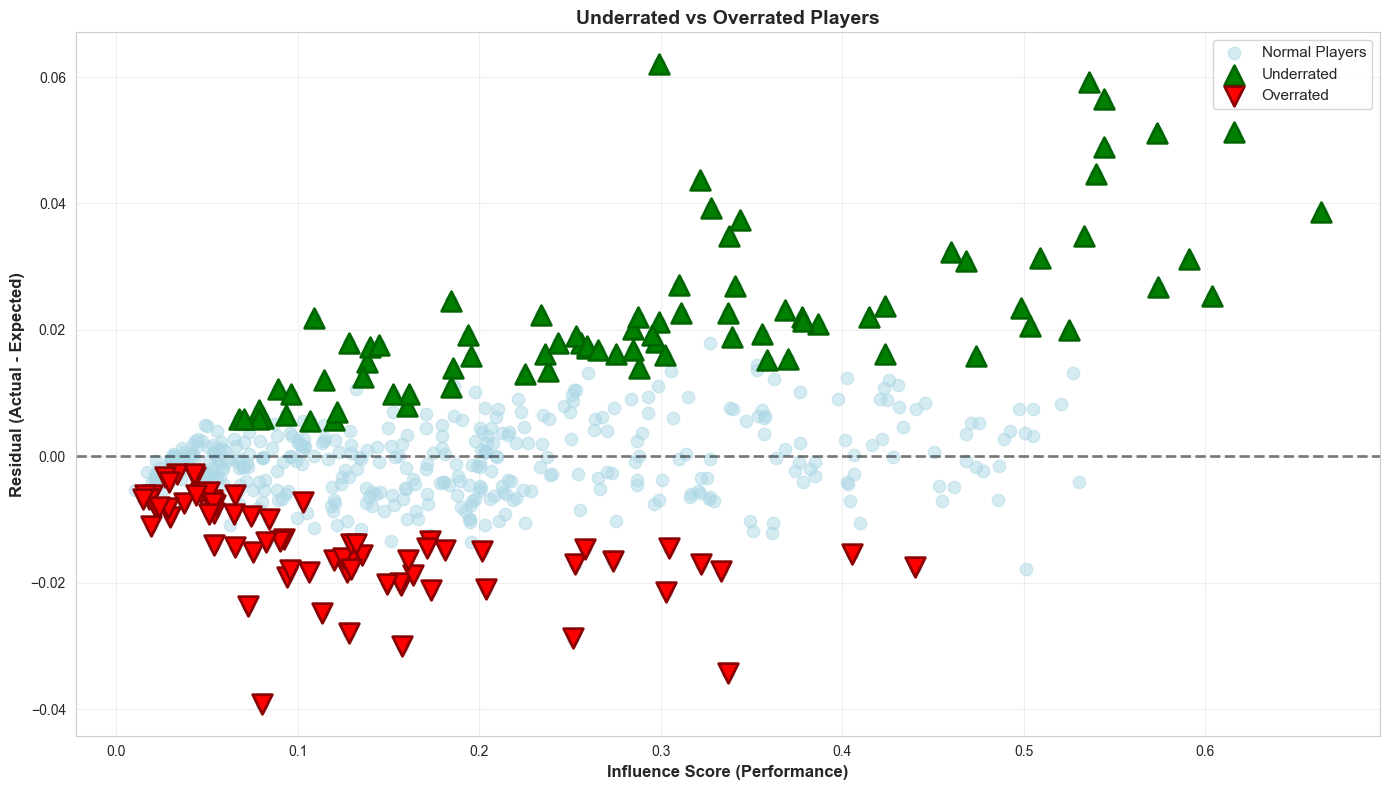

✓ Saved: simple_underrated_overrated.png


C:\Users\melke\AppData\Local\Temp\ipykernel_18332\2762619966.py:55: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\melke\AppData\Local\Temp\ipykernel_18332\2762619966.py:56: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) Arial.
  plt.savefig("simple_top_underrated.png", dpi=300)
C:\Users\melke\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


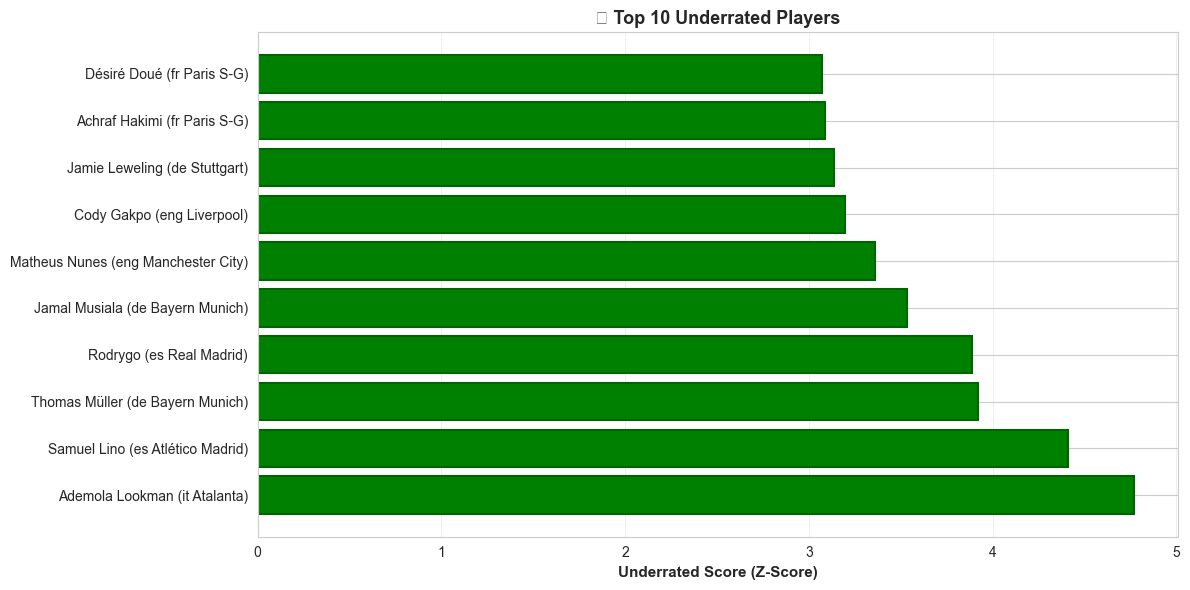

✓ Saved: simple_top_underrated.png


C:\Users\melke\AppData\Local\Temp\ipykernel_18332\2762619966.py:77: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\melke\AppData\Local\Temp\ipykernel_18332\2762619966.py:78: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  plt.savefig("simple_top_overrated.png", dpi=300)
C:\Users\melke\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


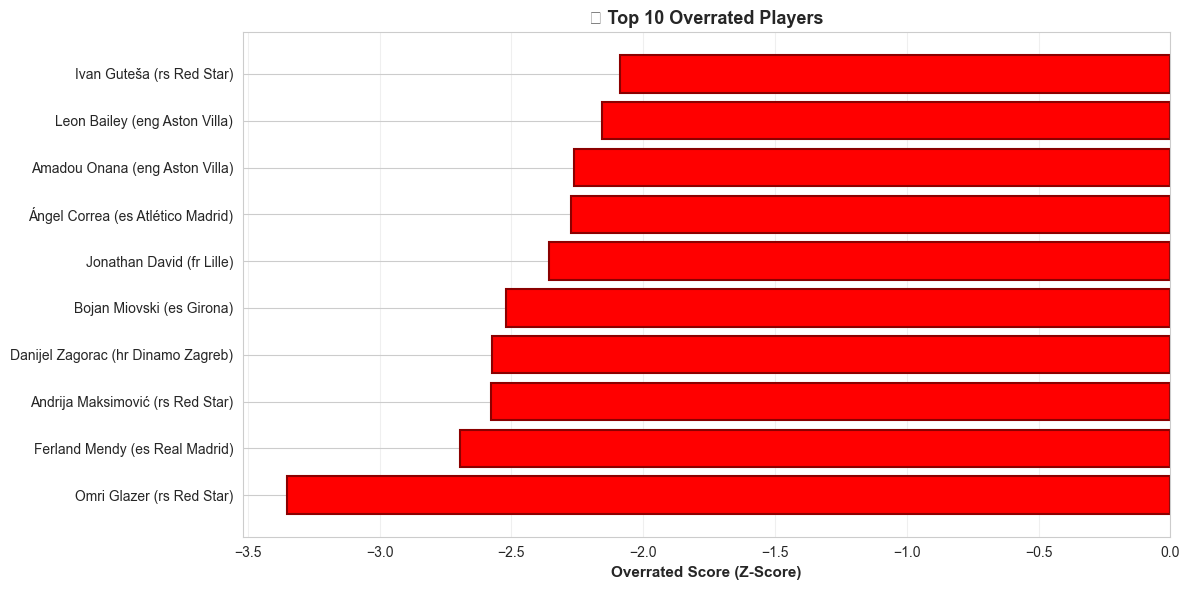

C:\Users\melke\AppData\Local\Temp\ipykernel_18332\2762619966.py:104: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(cluster_data, labels=[f"C{int(c)}" for c in sorted(clusters)],
C:\Users\melke\AppData\Local\Temp\ipykernel_18332\2762619966.py:104: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(cluster_data, labels=[f"C{int(c)}" for c in sorted(clusters)],
C:\Users\melke\AppData\Local\Temp\ipykernel_18332\2762619966.py:104: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(cluster_data, labels=[f"C{int(c)}" for c in sorted(clusters)],


✓ Saved: simple_top_overrated.png


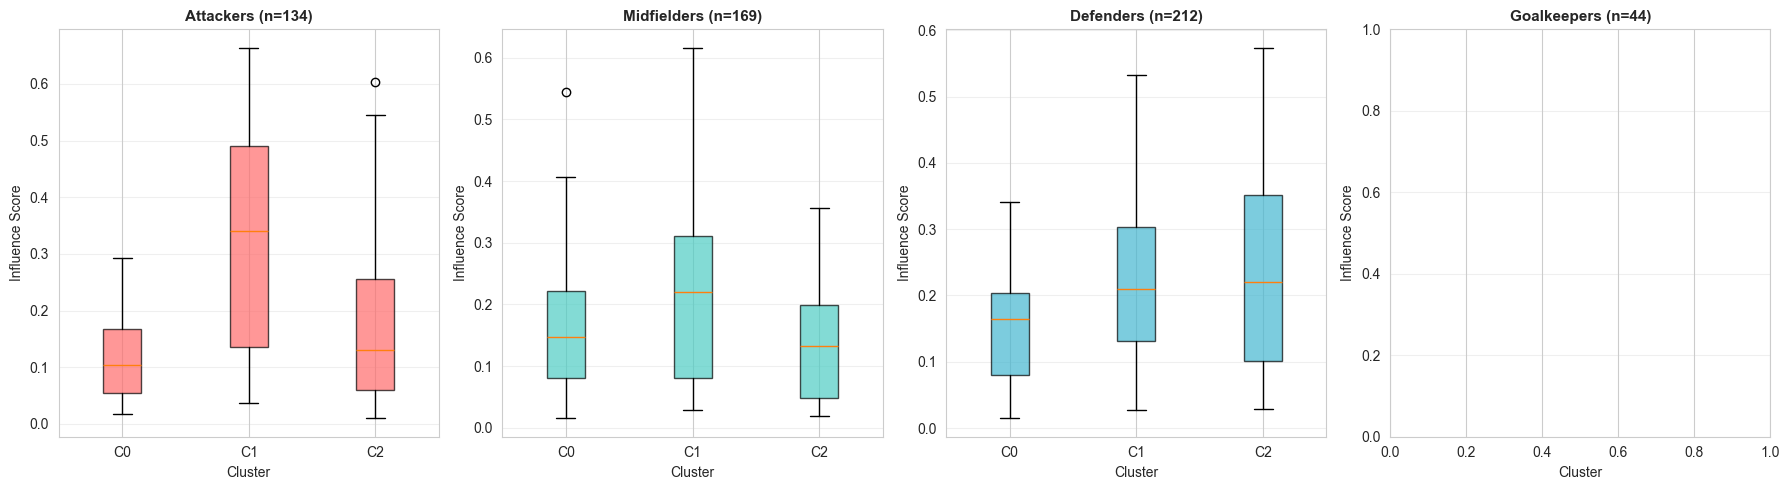

✓ Saved: simple_clusters_by_role.png


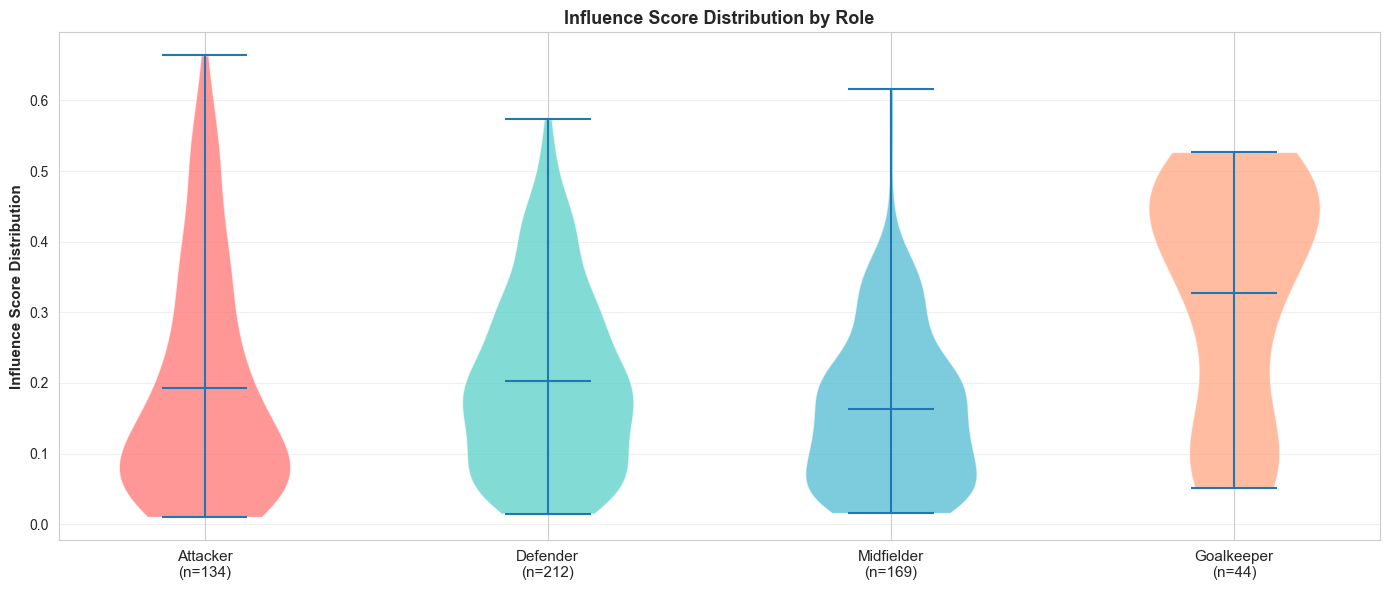

✓ Saved: simple_distribution_by_role.png


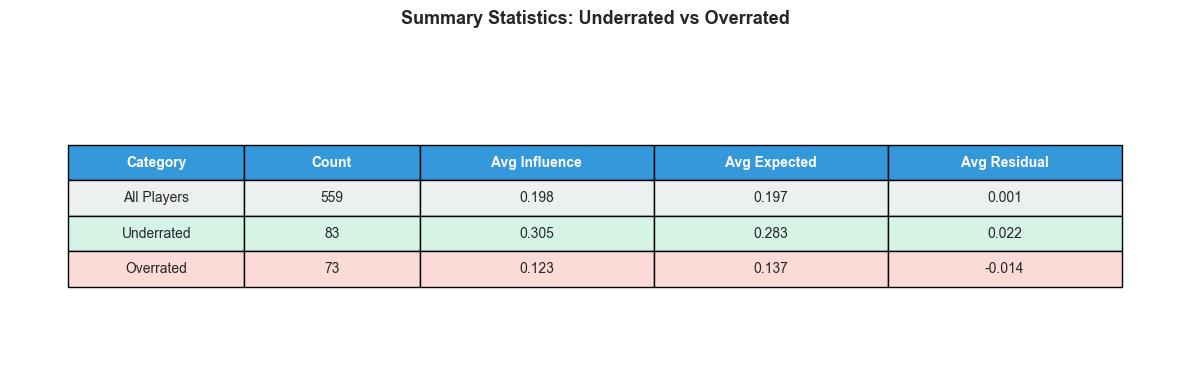

✓ Saved: simple_comparison_table.png

📊 QUICK SUMMARY

✅ Total Players Analyzed: 559
✅ Underrated Players: 83
✅ Overrated Players: 73

🌟 TOP 5 UNDERRATED:
   Ademola Lookman           (it Atalanta    ) - Z-Score: +4.77
   Samuel Lino               (es Atlético Madrid) - Z-Score: +4.41
   Thomas Müller             (de Bayern Munich) - Z-Score: +3.92
   Rodrygo                   (es Real Madrid ) - Z-Score: +3.89
   Jamal Musiala             (de Bayern Munich) - Z-Score: +3.54

💰 TOP 5 OVERRATED:
   Omri Glazer               (rs Red Star    ) - Z-Score: -3.35
   Ferland Mendy             (es Real Madrid ) - Z-Score: -2.70
   Andrija Maksimović        (rs Red Star    ) - Z-Score: -2.58
   Danijel Zagorac           (hr Dinamo Zagreb) - Z-Score: -2.57
   Bojan Miovski             (es Girona      ) - Z-Score: -2.52

✓ All visualizations saved!


In [ ]:
df = pd.read_csv("uefa_subrole_full_output_v2.csv")
plt.figure(figsize=(14, 8))
plt.scatter(df["InfluenceScore"], df["Residual"], 
           alpha=0.5, s=80, color='lightblue', label='Normal Players')

underrated = df[df["Residual_z"] > 1.0]
plt.scatter(underrated["InfluenceScore"], underrated["Residual"],
           marker='^', s=200, color='green', edgecolor='darkgreen', 
           linewidth=2, label='Underrated', zorder=5)

overrated = df[df["Residual_z"] < -1.0]
plt.scatter(overrated["InfluenceScore"], overrated["Residual"],
           marker='v', s=200, color='red', edgecolor='darkred',
           linewidth=2, label='Overrated', zorder=5)

plt.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.5)

plt.xlabel("Influence Score (Performance)", fontsize=12, weight='bold')
plt.ylabel("Residual (Actual - Expected)", fontsize=12, weight='bold')
plt.title("Underrated vs Overrated Players", fontsize=14, weight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("simple_underrated_overrated.png", dpi=300)
plt.show()

print(" Saved: simple_underrated_overrated.png")

top_underrated = underrated.nlargest(10, "Residual_z")

plt.figure(figsize=(12, 6))
bars = plt.barh(range(len(top_underrated)), top_underrated["Residual_z"], 
               color='green', edgecolor='darkgreen', linewidth=1.5)

plt.yticks(range(len(top_underrated)), 
          [f"{row['Player']} ({row['Squad']})" 
           for _, row in top_underrated.iterrows()], fontsize=10)

plt.xlabel("Underrated Score (Z-Score)", fontsize=11, weight='bold')
plt.title(" Top 10 Underrated Players", fontsize=13, weight='bold')
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig("simple_top_underrated.png", dpi=300)
plt.show()

print(" Saved: simple_top_underrated.png")

top_overrated = overrated.nsmallest(10, "Residual_z")

plt.figure(figsize=(12, 6))
bars = plt.barh(range(len(top_overrated)), top_overrated["Residual_z"],
               color='red', edgecolor='darkred', linewidth=1.5)

plt.yticks(range(len(top_overrated)),
          [f"{row['Player']} ({row['Squad']})"
           for _, row in top_overrated.iterrows()], fontsize=10)

plt.xlabel("Overrated Score (Z-Score)", fontsize=11, weight='bold')
plt.title("💰 Top 10 Overrated Players", fontsize=13, weight='bold')
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig("simple_top_overrated.png", dpi=300)
plt.show()

print(" Saved: simple_top_overrated.png")

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

roles = ["Attacker", "Midfielder", "Defender", "Goalkeeper"]
colors_role = {'Attacker': '#FF6B6B', 'Midfielder': '#4ECDC4', 
               'Defender': '#45B7D1', 'Goalkeeper': '#FFA07A'}

for idx, role in enumerate(roles):
    ax = axes[idx]
    role_data = df[df["Role"] == role]
    
    if f"subrole_{role}" in df.columns:
        cluster_col = f"subrole_{role}"
        
        clusters = role_data[cluster_col].unique()
        cluster_data = [role_data[role_data[cluster_col] == c]["InfluenceScore"].values 
                       for c in sorted(clusters)]
        
        bp = ax.boxplot(cluster_data, labels=[f"C{int(c)}" for c in sorted(clusters)],
                       patch_artist=True)
        
        for patch in bp['boxes']:
            patch.set_facecolor(colors_role[role])
            patch.set_alpha(0.7)
    
    ax.set_title(f"{role}s (n={len(role_data)})", fontsize=11, weight='bold')
    ax.set_ylabel("Influence Score", fontsize=10)
    ax.set_xlabel("Cluster", fontsize=10)
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("simple_clusters_by_role.png", dpi=300)
plt.show()

print(" Saved: simple_clusters_by_role.png")

plt.figure(figsize=(14, 6))

plot_data = []
role_labels = []
for role in df["Role"].unique():
    role_df = df[df["Role"] == role]["InfluenceScore"]
    plot_data.append(role_df.dropna().values)
    role_labels.append(f"{role}\n(n={len(role_df)})")

parts = plt.violinplot(plot_data, positions=range(len(plot_data)), 
                       showmeans=True, showextrema=True)

s
colors_list = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#95E1D3']
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors_list[i % len(colors_list)])
    pc.set_alpha(0.7)

plt.xticks(range(len(plot_data)), role_labels, fontsize=11)
plt.ylabel("Influence Score Distribution", fontsize=11, weight='bold')
plt.title("Influence Score Distribution by Role", fontsize=13, weight='bold')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("simple_distribution_by_role.png", dpi=300)
plt.show()

print("✓ Saved: simple_distribution_by_role.png")

summary_stats = pd.DataFrame({
    'Category': ['All Players', 'Underrated', 'Overrated'],
    'Count': [len(df), len(underrated), len(overrated)],
    'Avg Influence': [
        df["InfluenceScore"].mean(),
        underrated["InfluenceScore"].mean(),
        overrated["InfluenceScore"].mean()
    ],
    'Avg Expected': [
        df["ExpectedInfluence"].mean(),
        underrated["ExpectedInfluence"].mean(),
        overrated["ExpectedInfluence"].mean()
    ],
    'Avg Residual': [
        df["Residual"].mean(),
        underrated["Residual"].mean(),
        overrated["Residual"].mean()
    ]
})

fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=summary_stats.round(3).values,
                colLabels=summary_stats.columns,
                cellLoc='center',
                loc='center',
                colWidths=[0.15, 0.15, 0.2, 0.2, 0.2])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

for i in range(len(summary_stats.columns)):
    table[(0, i)].set_facecolor('#3498db')
    table[(0, i)].set_text_props(weight='bold', color='white')


for i in range(1, len(summary_stats) + 1):
    if i == 1:
        color = '#ecf0f1'
    elif i == 2:
        color = '#d5f4e6' 
    else:
        color = '#fadbd8'  
    
    for j in range(len(summary_stats.columns)):
        table[(i, j)].set_facecolor(color)

plt.title("Summary Statistics: Underrated vs Overrated", 
         fontsize=13, weight='bold', pad=20)
plt.tight_layout()
plt.savefig("simple_comparison_table.png", dpi=300, bbox_inches='tight')
plt.show()

print(" Saved: simple_comparison_table.png")

print("\n" + "="*60)
print(" QUICK SUMMARY")
print("="*60)
print(f"\n Total Players Analyzed: {len(df)}")
print(f" Underrated Players: {len(underrated)}")
print(f" Overrated Players: {len(overrated)}")
print(f"\n TOP 5 UNDERRATED:")
for idx, row in underrated.nlargest(5, "Residual_z").iterrows():
    print(f"   {row['Player']:25} ({row['Squad']:15}) - Z-Score: {row['Residual_z']:+.2f}")

print(f"\nTOP 5 OVERRATED:")
for idx, row in overrated.nsmallest(5, "Residual_z").iterrows():
    print(f"   {row['Player']:25} ({row['Squad']:15}) - Z-Score: {row['Residual_z']:+.2f}")

print("\n All visualizations saved!")
print("="*60)


In [ ]:
# ---------- Add GMM confidence weighting to SubroleFinalScore ----------
if 'df' not in globals():
    raise RuntimeError("DataFrame `df` not found in memory. Run the main pipeline first.")

if 'subrole_map' not in globals():
   
    subrole_cols = [c for c in df.columns if c.startswith("subrole_") and not c.endswith(("_p0","_p1"))]
    subrole_map = {c.split("subrole_")[1]: c for c in subrole_cols}
else:
   
    pass

applied = []
for role, col in (subrole_map.items() if isinstance(subrole_map, dict) else []):
    
    if col is None or col not in df.columns:
        continue
    conf_col = f"{col}_p0"
    if conf_col not in df.columns:
        df[conf_col] = df.get(conf_col, 0.5)
    df[conf_col] = df[conf_col].fillna(0.5).astype(float)
    scale_col = f"{col}_scale"
    df[scale_col] = 0.8 + 0.2 * df[conf_col]
    mask = (df["Role"] == role) & df[col].notna()
    if "SubroleFinalScore" not in df.columns:
        df["PositionAwareInfluence"] = df.get("PositionAwareInfluence", df["InfluenceScore"].rank(pct=True))
        df["SubroleFinalScore"] = df["PositionAwareInfluence"]
    df.loc[mask, "SubroleFinalScore"] = df.loc[mask, "SubroleFinalScore"] * df.loc[mask, scale_col]
    applied.append(role)

df["SubroleFinalScore"] = df["SubroleFinalScore"].fillna(df.get("PositionAwareInfluence", df["InfluenceScore"].rank(pct=True)))
RELIABLE_90S = globals().get("RELIABLE_90S", 5.0)
reliable_mask = df["90s"] >= RELIABLE_90S
underrated_subrole = df[(df["Residual_z"] > 1.0) & reliable_mask].sort_values("Residual_z", ascending=False)
overrated_subrole  = df[(df["Residual_z"] < -1.0) & reliable_mask].sort_values("Residual_z")
OUT_COLS = [
    "Player","Squad","Role","90s","InfluenceScore","ExpectedInfluence",
    "Residual","Residual_z","IsoFlag","SubroleFinalScore"
]
underrated_subrole.head(40)[OUT_COLS].to_csv("underrated_subrole_v2_gmmconf.csv", index=False)
overrated_subrole.head(40)[OUT_COLS].to_csv("overrated_subrole_v2_gmmconf.csv", index=False)
df.to_csv("uefa_subrole_full_output_v2_gmmconf.csv", index=False)
print("Applied GMM-confidence scaling to subroles for roles:", applied)
print("Saved: underrated_subrole_v2_gmmconf.csv, overrated_subrole_v2_gmmconf.csv, uefa_subrole_full_output_v2_gmmconf.csv")
print("Top 10 underrated (after scaling):")
display(underrated_subrole[OUT_COLS].head(10))
print("Top 10 overrated (after scaling):")
display(overrated_subrole[OUT_COLS].head(10))
print("Uploaded file reference (local):", "/mnt/data/Mini.docx")


Applied GMM-confidence scaling to subroles for roles: ['Attacker', 'Midfielder', 'Defender']
Saved: underrated_subrole_v2_gmmconf.csv, overrated_subrole_v2_gmmconf.csv, uefa_subrole_full_output_v2_gmmconf.csv
Top 10 underrated (after scaling):


,Player,Squad,Role,90s,InfluenceScore,ExpectedInfluence,Residual,Residual_z,IsoFlag,SubroleFinalScore
4,Ademola Lookman,it Atalanta,Attacker,5.3,0.298997,0.236976,0.062021,4.771345,-1,0.418075
459,Rodrygo,es Real Madrid,Midfielder,9.7,0.544037,0.487525,0.056512,3.890450,-1,0.937436
221,Jamal Musiala,de Bayern Munich,Midfielder,9.6,0.615900,0.564523,0.051377,3.536955,-1,0.999200
353,Matheus Nunes,eng Manchester City,Midfielder,5.9,0.321696,0.277996,0.043700,3.361879,-1,0.498057
1,Achraf Hakimi,fr Paris S-G,Defender,17.1,0.536191,0.477014,0.059177,3.090223,-1,0.911537
132,Désiré Doué,fr Paris S-G,Attacker,8.2,0.539668,0.495038,0.044630,3.072503,-1,0.756684
25,Amar Dedić,at RB Salzburg,Defender,7.0,0.327629,0.288328,0.039301,3.023431,1,0.514750
522,Viktor Gyökeres,pt Sporting CP,Attacker,6.8,0.343716,0.306276,0.037441,2.880346,1,0.489215
345,Martin Baturina,hr Dinamo Zagreb,Midfielder,6.9,0.337581,0.302705,0.034877,2.683107,1,0.607194
406,Nuno Mendes,fr Paris S-G,Defender,16.1,0.573449,0.522340,0.051109,2.668949,-1,0.998556


Top 10 overrated (after scaling):


,Player,Squad,Role,90s,InfluenceScore,ExpectedInfluence,Residual,Residual_z,IsoFlag,SubroleFinalScore
158,Ferland Mendy,es Real Madrid,Defender,9.8,0.080496,0.119657,-0.039161,-2.695944,-1,0.200489
242,Jonathan David,fr Lille,Attacker,8.3,0.337158,0.371396,-0.034239,-2.357101,-1,0.478884
301,Leon Bailey,eng Aston Villa,Attacker,5.8,0.128395,0.156407,-0.028012,-2.155005,1,0.198611
160,Ferran Jutglà,be Club Brugge,Attacker,9.4,0.157202,0.187301,-0.030099,-2.072106,-1,0.464811
33,Anis Hadj Moussa,nl Feyenoord,Attacker,8.7,0.251774,0.280552,-0.028778,-1.981181,1,0.405911
444,Raphaël Guerreiro,de Bayern Munich,Defender,5.8,0.113046,0.137839,-0.024794,-1.907400,1,0.296749
385,Myles Lewis-Skelly,eng Arsenal,Defender,6.3,0.072663,0.096420,-0.023757,-1.827672,1,0.176488
400,Niklas Geyrhofer,at Sturm Graz,Defender,5.0,0.084246,0.094210,-0.009964,-1.784056,1,0.203392
468,Rúben Dias,eng Manchester City,Defender,5.0,0.074000,0.083382,-0.009383,-1.679929,1,0.172286
532,Willi Orban,de RB Leipzig,Defender,8.0,0.302761,0.324223,-0.021462,-1.651096,1,0.484255


Uploaded file reference (local): /mnt/data/Mini.docx
